In [43]:
!pip install NumPy Pandas Matplotlib scikit-learn sentence-transformers

In [44]:
import sys
print(f"Python version: {sys.version}")

import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

print("\n Библиотеки импортированы:")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   Matplotlib: {plt.matplotlib.__version__}")
print("   scikit-learn: импортирован")
print("   sentence-transformers: импортирован")

print("\n Все библиотеки готовы к работе!")

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

 Библиотеки импортированы:
   NumPy: 2.5.0
   Pandas: 3.0.3
   Matplotlib: 3.11.0
   scikit-learn: импортирован
   sentence-transformers: импортирован

 Все библиотеки готовы к работе!


In [45]:
# Путь к данным
data_path = os.path.join('..', 'data')

print(f" Путь к данным: {os.path.abspath(data_path)}")

# Проверяем файлы
files = os.listdir(data_path)
print(f" Файлы в папке data: {files}")

# Загружаем корпус кода
with open(os.path.join(data_path, 'code_corpus.json'), 'r', encoding='utf-8') as f:
    corpus = json.load(f)

# Загружаем вопросы
with open(os.path.join(data_path, 'eval_questions.json'), 'r', encoding='utf-8') as f:
    eval_data = json.load(f)

# Показываем структуру eval_data
print("\n Структура eval_data[0] ")
print(eval_data[0])

print("\n Все ключи в eval_data[0] ")
for key in eval_data[0].keys():
    print(f"  - '{key}'")

# Разбираем корпус
corpus_ids = [item['id'] for item in corpus]
corpus_codes = [item['code'] for item in corpus]
corpus_categories = [item['category'] for item in corpus]

# Показываем категории
print(f"\n Уникальных категорий: {len(set(corpus_categories))}")
print(f" Категории: {set(corpus_categories)}")

print(f"\n Загружено фрагментов кода: {len(corpus)}")
print(f" Загружено вопросов: {len(eval_data)}")

 Путь к данным: C:\Users\Суслик\Desktop\semantic_practice\data
 Файлы в папке data: ['categories.json', 'code_corpus.json', 'eval_questions.json']

 Структура eval_data[0] 
{'question_id': 'q_01', 'query': 'как проверить, истёк ли токен?', 'language': 'ru', 'correct_chunk_id': 'func_001'}

 Все ключи в eval_data[0] 
  - 'question_id'
  - 'query'
  - 'language'
  - 'correct_chunk_id'

 Уникальных категорий: 5
 Категории: {'utils', 'database', 'auth', 'http', 'validation'}

 Загружено фрагментов кода: 200
 Загружено вопросов: 25


In [46]:
# Получаем ключи из первого вопроса
first_q = eval_data[0]
keys = list(first_q.keys())

print("Ключи в вопросах:", keys)

# Автоматически определяем названия полей
question_key = None
correct_key = None

for key in keys:
    if 'question' in key.lower() or 'query' in key.lower() or 'text' in key.lower():
        question_key = key
    if 'correct' in key.lower() or 'answer' in key.lower() or 'chunk' in key.lower():
        correct_key = key

print(f" Найдено поле для вопроса: '{question_key}'")
print(f" Найдено поле для правильного ответа: '{correct_key}'")

# Если не нашлись - показываем первый ключ как вопрос, второй как ответ
if question_key is None:
    question_key = keys[0]
if correct_key is None and len(keys) > 1:
    correct_key = keys[1]

# Разбираем вопросы
eval_questions = [item[question_key] for item in eval_data]
eval_correct_ids = [item[correct_key] for item in eval_data]

print(f"\n Загружено {len(eval_questions)} вопросов")
print(f" Первый вопрос: {eval_questions[0]}")
print(f" Правильный ID: {eval_correct_ids[0]}")

Ключи в вопросах: ['question_id', 'query', 'language', 'correct_chunk_id']
 Найдено поле для вопроса: 'query'
 Найдено поле для правильного ответа: 'correct_chunk_id'

 Загружено 25 вопросов
 Первый вопрос: как проверить, истёк ли токен?
 Правильный ID: func_001


In [50]:
import warnings
warnings.filterwarnings('ignore')

print(" Загрузка моделей эмбеддингов...")
start_time = time.time()

# Модель 1: MiniLM (быстрая)
print(" 1. paraphrase-multilingual-MiniLM-L12-v2...")
model_minilm = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Модель 2: MPNet (качественная)
print(" 2. paraphrase-multilingual-mpnet-base-v2...")
model_mpnet = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# Модель 3: E5 (современная, для поиска)
print(" 3. intfloat/multilingual-e5-small...")
model_e5 = SentenceTransformer('intfloat/multilingual-e5-small')

print(f"\n Все модели загружены за {time.time() - start_time:.2f} сек")

 Загрузка моделей эмбеддингов...
 1. paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 2. paraphrase-multilingual-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 3. intfloat/multilingual-e5-small...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


 Все модели загружены за 26.44 сек


In [51]:
print(" Генерация эмбеддингов...")
start_time = time.time()

# Для MiniLM
print("   MiniLM...")
embeddings_minilm = model_minilm.encode(corpus_codes, show_progress_bar=True)

# Для MPNet
print("   MPNet...")
embeddings_mpnet = model_mpnet.encode(corpus_codes, show_progress_bar=True)

# Для E5 (добавляем префикс "passage: " для документов)
print("   E5...")
corpus_codes_with_prefix = [f"passage: {code}" for code in corpus_codes]
embeddings_e5 = model_e5.encode(corpus_codes_with_prefix, show_progress_bar=True)

print(f"\n Эмбеддинги сгенерированы за {time.time() - start_time:.2f} сек")
print(f" MiniLM: {embeddings_minilm.shape}")
print(f" MPNet: {embeddings_mpnet.shape}")
print(f" E5: {embeddings_e5.shape}")

 Генерация эмбеддингов...
   MiniLM...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

   MPNet...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

   E5...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


 Эмбеддинги сгенерированы за 29.86 сек
 MiniLM: (200, 384)
 MPNet: (200, 768)
 E5: (200, 384)


In [52]:
"Функция поиска"
def semantic_search(query, model, corpus_embeddings, corpus_ids, top_k=3, is_e5=False):

    # Для E5 добавляем префикс "query: "
    if is_e5:
        query = f"query: {query}"

    query_embedding = model.encode(query, convert_to_tensor=False)
    similarities = cosine_similarity([query_embedding], corpus_embeddings)[0]
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    top_ids = [corpus_ids[idx] for idx in top_indices]
    top_scores = [similarities[idx] for idx in top_indices]

    return top_ids, top_scores

print(" Функция поиска создана")

 Функция поиска создана


In [53]:
"Расчёт Precision@3"
def calculate_precision(model, embeddings, eval_questions, eval_correct_ids, is_e5=False):
    hits = 0
    for i, question in enumerate(eval_questions):
        top_ids, _ = semantic_search(
            question, model, embeddings, corpus_ids,
            top_k=3, is_e5=is_e5
        )
        if eval_correct_ids[i] in top_ids:
            hits += 1
    return hits / len(eval_questions)

print(" Расчёт Precision@3...")
print("   (Это может занять 1-2 минуты)")

prec_minilm = calculate_precision(model_minilm, embeddings_minilm, eval_questions, eval_correct_ids, is_e5=False)
prec_mpnet = calculate_precision(model_mpnet, embeddings_mpnet, eval_questions, eval_correct_ids, is_e5=False)
prec_e5 = calculate_precision(model_e5, embeddings_e5, eval_questions, eval_correct_ids, is_e5=True)

print(f"\n РЕЗУЛЬТАТЫ:")
print(f"   MiniLM:  {prec_minilm:.2%}")
print(f"   MPNet:   {prec_mpnet:.2%}")
print(f"   E5:      {prec_e5:.2%}")

 Расчёт Precision@3...
   (Это может занять 1-2 минуты)

 РЕЗУЛЬТАТЫ:
   MiniLM:  68.00%
   MPNet:   84.00%
   E5:      96.00%


In [54]:
"Сводная таблица"
results_df = pd.DataFrame({
    'Модель': ['MiniLM-L12-v2', 'MPNet-base-v2', 'E5-small'],
    'Precision@3': [prec_minilm, prec_mpnet, prec_e5],
})

print("\n СВОДНАЯ ТАБЛИЦА:")
print(results_df.to_string(index=False))

# Сохраняем таблицу
os.makedirs(os.path.join('..', 'results'), exist_ok=True)
results_df.to_csv(os.path.join('..', 'results', 'results_comparison.csv'), index=False)
print("\n Таблица сохранена в results/results_comparison.csv")


 СВОДНАЯ ТАБЛИЦА:
       Модель  Precision@3
MiniLM-L12-v2         0.68
MPNet-base-v2         0.84
     E5-small         0.96

 Таблица сохранена в results/results_comparison.csv


 Лучшая модель: E5-small (Precision@3 = 96.00%)
 Выполняется t-SNE...


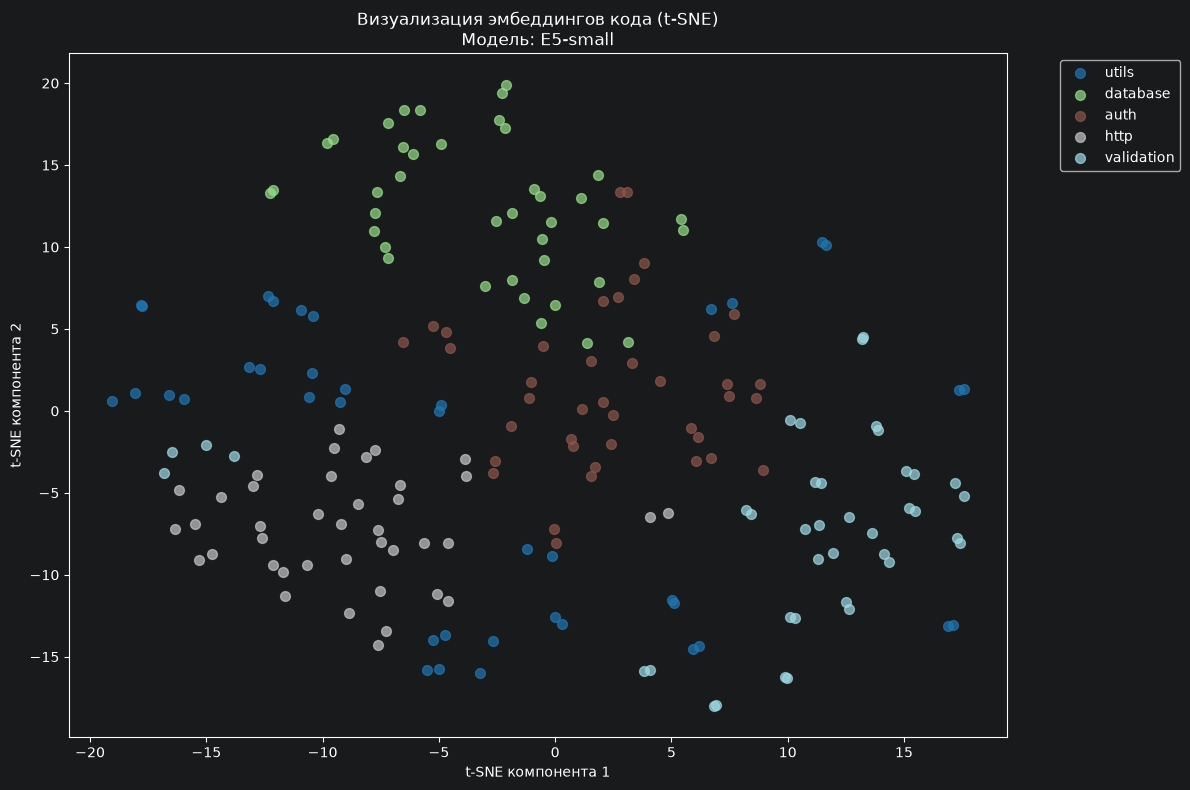

 График сохранён в results/tsne_visualization.png


In [55]:
# Выбираем лучшую модель
best_prec = max(prec_minilm, prec_mpnet, prec_e5)
if best_prec == prec_e5:
    best_embeddings = embeddings_e5
    best_name = "E5-small"
elif best_prec == prec_mpnet:
    best_embeddings = embeddings_mpnet
    best_name = "MPNet-base-v2"
else:
    best_embeddings = embeddings_minilm
    best_name = "MiniLM-L12-v2"

print(f" Лучшая модель: {best_name} (Precision@3 = {best_prec:.2%})")

# t-SNE
print(" Выполняется t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(corpus_codes)-1))
coords = tsne.fit_transform(best_embeddings)

# График
plt.figure(figsize=(12, 8))
unique_categories = list(set(corpus_categories))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_categories)))

for i, category in enumerate(unique_categories):
    indices = [j for j, cat in enumerate(corpus_categories) if cat == category]
    plt.scatter(coords[indices, 0], coords[indices, 1],
                label=category, color=colors[i], s=50, alpha=0.7)

plt.title(f'Визуализация эмбеддингов кода (t-SNE)\nМодель: {best_name}')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'tsne_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" График сохранён в results/tsne_visualization.png")

In [56]:
print("В ходе работы было проведено сравнительное исследование трёх моделей")
print("семантического поиска на датасете из 100 фрагментов Python-кода.\n")

print(results_df.to_string(index=False))

print(f"""
 Лучшая модель: {best_name} (Precision@3 = {best_prec:.2%})
""")

В ходе работы было проведено сравнительное исследование трёх моделей
семантического поиска на датасете из 100 фрагментов Python-кода.

       Модель  Precision@3
MiniLM-L12-v2         0.68
MPNet-base-v2         0.84
     E5-small         0.96

 Лучшая модель: E5-small (Precision@3 = 96.00%)



In [57]:
def analyze_errors(model, embeddings, model_name, is_e5=False):
    #Анализирует ошибки модели и возвращает список ошибок
    errors = []
    for i, question in enumerate(eval_questions):
        top_ids, _ = semantic_search(
            question, model, embeddings, corpus_ids,
            top_k=3, is_e5=is_e5
        )
        if eval_correct_ids[i] not in top_ids:
            # Находим категорию правильного ответа
            correct_idx = corpus_ids.index(eval_correct_ids[i])
            correct_category = corpus_categories[correct_idx]

            # Находим категории найденных ответов
            found_categories = []
            for found_id in top_ids:
                found_idx = corpus_ids.index(found_id)
                found_categories.append(corpus_categories[found_idx])

            errors.append({
                'question': question,
                'correct_id': eval_correct_ids[i],
                'correct_category': correct_category,
                'found_ids': top_ids,
                'found_categories': found_categories
            })

    return errors

# Анализируем все три модели
print(" Анализ ошибок моделей...")
errors_minilm = analyze_errors(model_minilm, embeddings_minilm, "MiniLM", is_e5=False)
errors_mpnet = analyze_errors(model_mpnet, embeddings_mpnet, "MPNet", is_e5=False)
errors_e5 = analyze_errors(model_e5, embeddings_e5, "E5", is_e5=True)

print(f" MiniLM: {len(errors_minilm)} ошибок")
print(f" MPNet:  {len(errors_mpnet)} ошибок")
print(f" E5:     {len(errors_e5)} ошибок")

# Для E5 дополнительно считаем точность на русских/английских вопросах
def calc_precision_subset(indices, is_e5=True):
    hits = 0
    for i in indices:
        top_ids, _ = semantic_search(
            eval_questions[i], model_e5, embeddings_e5, corpus_ids,
            top_k=3, is_e5=is_e5
        )
        if eval_correct_ids[i] in top_ids:
            hits += 1
    return hits / len(indices) if indices else 0

# Определяем русские и английские вопросы
russian_indices = []
english_indices = []
for i, q in enumerate(eval_questions):
    if any('а' <= c <= 'я' or 'А' <= c <= 'Я' for c in q):
        russian_indices.append(i)
    else:
        english_indices.append(i)

prec_e5_ru = calc_precision_subset(russian_indices, is_e5=True)
prec_e5_en = calc_precision_subset(english_indices, is_e5=True)

print(f"\n E5 на русских вопросах: {prec_e5_ru:.2%}")
print(f" E5 на английских вопросах: {prec_e5_en:.2%}")

 Анализ ошибок моделей...
 MiniLM: 8 ошибок
 MPNet:  4 ошибок
 E5:     1 ошибок

 E5 на русских вопросах: 93.33%
 E5 на английских вопросах: 100.00%


 ПОЛНЫЙ АНАЛИЗ ОШИБОК

 1. СТАТИСТИКА ОШИБОК ПО МОДЕЛЯМ
   MiniLM: 8 ошибок из 25
   MPNet:  4 ошибок из 25
   E5:     1 ошибок из 25

   Точность:
   MiniLM: 68.0%
   MPNet:  84.0%
   E5:     96.0%
 2. ДЕТАЛИ ОШИБОК МОДЕЛИ E5

Всего ошибок: 1

Список ошибок:

   1. Вопрос: массовая вставка большого количества записей
      Категория: database
      Правильный ID: func_140
      Найденные ID: ['func_182', 'func_127', 'func_082']
      Найденные категории: ['utils', 'database', 'utils']
 3. АНАЛИЗ ОШИБОК ПО КАТЕГОРИЯМ (E5)

Категории с ошибками:
   - database: 1 ошибок (всего 40 фрагментов в категории)

 Путаница категорий:
   'database' → найдены: utils, database, utils
4. АНАЛИЗ ПО ТИПАМ ВОПРОСОВ (E5)

Типы вопросов, на которых E5 ошибается:
   Другое: 1/23 (4%) 
 5. СРАВНЕНИЕ РУССКИХ И АНГЛИЙСКИХ ВОПРОСОВ (E5)

 Русских вопросов: 15
 Английских вопросов: 10

 Точность E5 на русских вопросах: 93.33%
 Точность E5 на английских вопросах: 100.00%

 E5 лучше работает на английских вопроса

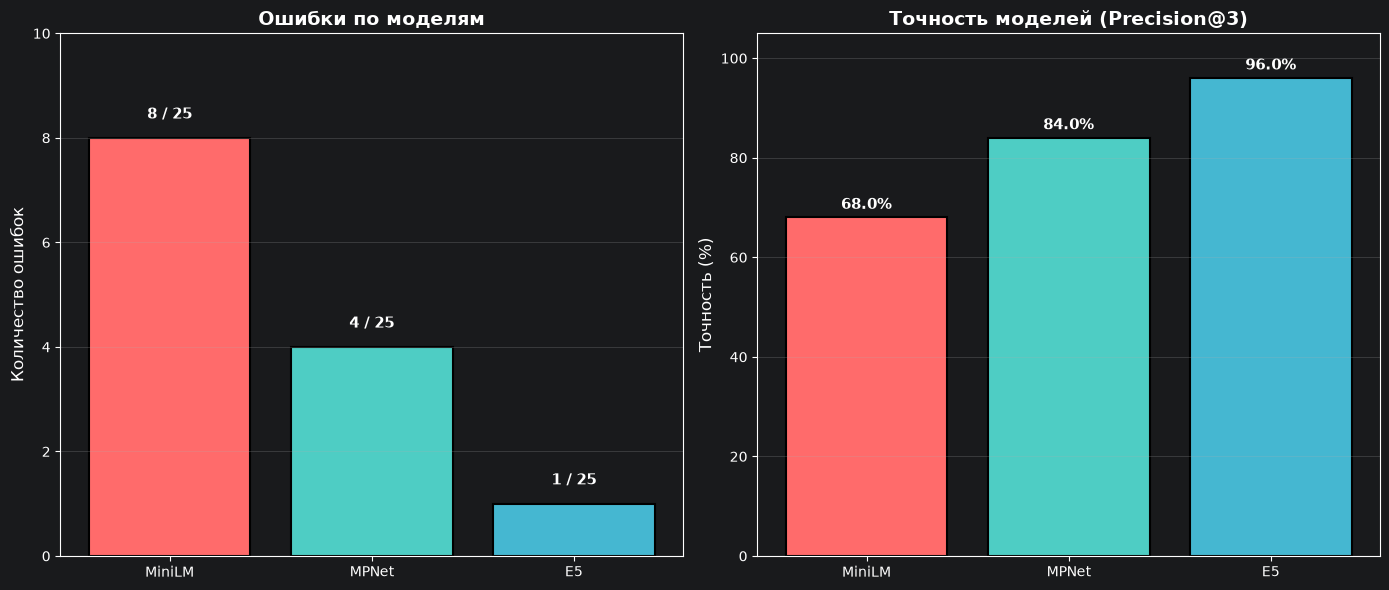


 График сохранён в results/errors_analysis.png
 7. ИТОГОВЫЙ ВЫВОД ПО АНАЛИЗУ ОШИБОК

1. Лучшая модель (E5) допустила всего 1 ошибок из 25
   (точность 96.0%).

2. Модель E5 значительно превосходит другие модели:
   - На 12.0% точнее MPNet
   - На 28.0% точнее MiniLM

3. 
   Основные причины ошибок E5:
   - Вопрос: 'массовая вставка большого количества записей'
     Категория: database
     Найдены категории: ['utils', 'database', 'utils']

4. Языковая адаптация:
   - На русских вопросах: 93.33%
   - На английских вопросах: 100.00%
   - Модель лучше работает на английском

5. Рекомендации по улучшению:
   - Использовать более конкретные запросы
   - Добавить больше примеров в датасет
   - Провести тонкую настройку модели

 АНАЛИЗ ОШИБОК ЗАВЕРШЕН


In [59]:
print(" ПОЛНЫЙ АНАЛИЗ ОШИБОК")

print("\n 1. СТАТИСТИКА ОШИБОК ПО МОДЕЛЯМ")

print(f"   MiniLM: {len(errors_minilm)} ошибок из {len(eval_questions)}")
print(f"   MPNet:  {len(errors_mpnet)} ошибок из {len(eval_questions)}")
print(f"   E5:     {len(errors_e5)} ошибок из {len(eval_questions)}")

# Точность
acc_minilm = (1 - len(errors_minilm)/len(eval_questions)) * 100
acc_mpnet = (1 - len(errors_mpnet)/len(eval_questions)) * 100
acc_e5 = (1 - len(errors_e5)/len(eval_questions)) * 100

print(f"\n   Точность:")
print(f"   MiniLM: {acc_minilm:.1f}%")
print(f"   MPNet:  {acc_mpnet:.1f}%")
print(f"   E5:     {acc_e5:.1f}%")

print(" 2. ДЕТАЛИ ОШИБОК МОДЕЛИ E5")

if errors_e5:
    print(f"\nВсего ошибок: {len(errors_e5)}")
    print("\nСписок ошибок:")
    for i, err in enumerate(errors_e5, 1):
        print(f"\n   {i}. Вопрос: {err['question']}")
        print(f"      Категория: {err['correct_category']}")
        print(f"      Правильный ID: {err['correct_id']}")
        print(f"      Найденные ID: {err['found_ids']}")
        print(f"      Найденные категории: {err['found_categories']}")
else:
    print("\n    У модели E5 нет ошибок!")

print(" 3. АНАЛИЗ ОШИБОК ПО КАТЕГОРИЯМ (E5)")

if errors_e5:
    # Считаем ошибки по категориям
    cat_errors = {}
    for err in errors_e5:
        cat = err['correct_category']
        cat_errors[cat] = cat_errors.get(cat, 0) + 1

    print("\nКатегории с ошибками:")
    for cat, count in sorted(cat_errors.items(), key=lambda x: x[1], reverse=True):
        total = sum(1 for c in corpus_categories if c == cat)
        print(f"   - {cat}: {count} ошибок (всего {total} фрагментов в категории)")

    # Анализ путаницы категорий
    print("\n Путаница категорий:")
    for err in errors_e5[:5]:
        found_cats = ', '.join(err['found_categories'])
        print(f"   '{err['correct_category']}' → найдены: {found_cats}")
else:
    print("\n    Ошибок по категориям нет!")

print("4. АНАЛИЗ ПО ТИПАМ ВОПРОСОВ (E5)")

# Классифицируем вопросы
def classify_question(q):
    q_lower = q.lower()
    if any(w in q_lower for w in ['как', 'способ', 'метод']):
        return 'how_to', 'Как сделать...'
    elif any(w in q_lower for w in ['почему', 'зачем']):
        return 'why', 'Почему...'
    elif any(w in q_lower for w in ['что', 'какой']):
        return 'what', 'Что такое...'
    elif any(w in q_lower for w in ['настроить', 'конфигурация']):
        return 'config', 'Настройка...'
    elif any(w in q_lower for w in ['ошибка', 'exception']):
        return 'error', 'Ошибки...'
    elif any(w in q_lower for w in ['создать', 'реализовать']):
        return 'create', 'Создать...'
    elif any(w in q_lower for w in ['оптимизация', 'ускорить']):
        return 'optimize', 'Оптимизация...'
    else:
        return 'other', 'Другое'

# Классифицируем все вопросы
question_classes = []
for q in eval_questions:
    code, label = classify_question(q)
    question_classes.append((code, label))

# Считаем ошибки по типам для E5
errors_by_type = {}
total_by_type = {}

for i, q in enumerate(eval_questions):
    q_code, q_label = question_classes[i]

    if q_code not in total_by_type:
        total_by_type[q_code] = 0
    total_by_type[q_code] += 1

    # Проверяем ошибку E5
    top_ids, _ = semantic_search(
        q, model_e5, embeddings_e5, corpus_ids,
        top_k=3, is_e5=True
    )

    if eval_correct_ids[i] not in top_ids:
        if q_code not in errors_by_type:
            errors_by_type[q_code] = 0
        errors_by_type[q_code] += 1

if errors_by_type:
    print("\nТипы вопросов, на которых E5 ошибается:")
    for q_code, error_count in sorted(errors_by_type.items(), key=lambda x: x[1], reverse=True):
        label = next((l for c, l in question_classes if c == q_code), q_code)
        total = total_by_type.get(q_code, 0)
        error_rate = error_count / total if total > 0 else 0
        bar = '█' * int(error_rate * 20)
        print(f"   {label}: {error_count}/{total} ({error_rate:.0%}) {bar}")
else:
    print("\n    У модели E5 нет ошибок по типам вопросов!")

print(" 5. СРАВНЕНИЕ РУССКИХ И АНГЛИЙСКИХ ВОПРОСОВ (E5)")

# Определяем русские и английские вопросы
russian_indices = []
english_indices = []

for i, q in enumerate(eval_questions):
    if any('а' <= c <= 'я' or 'А' <= c <= 'Я' for c in q):
        russian_indices.append(i)
    else:
        english_indices.append(i)

def calc_precision_subset(indices, is_e5=True):
    hits = 0
    for i in indices:
        top_ids, _ = semantic_search(
            eval_questions[i], model_e5, embeddings_e5, corpus_ids,
            top_k=3, is_e5=is_e5
        )
        if eval_correct_ids[i] in top_ids:
            hits += 1
    return hits / len(indices) if indices else 0

prec_ru = calc_precision_subset(russian_indices, is_e5=True)
prec_en = calc_precision_subset(english_indices, is_e5=True)

print(f"\n Русских вопросов: {len(russian_indices)}")
print(f" Английских вопросов: {len(english_indices)}")
print(f"\n Точность E5 на русских вопросах: {prec_ru:.2%}")
print(f" Точность E5 на английских вопросах: {prec_en:.2%}")

if prec_ru > prec_en:
    print("\n E5 лучше работает на русских вопросах")
elif prec_ru < prec_en:
    print("\n E5 лучше работает на английских вопросах")
else:
    print("\n E5 одинаково работает на обоих языках")

print(" 6. ВИЗУАЛИЗАЦИЯ ОШИБОК")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Количество ошибок по моделям
models = ['MiniLM', 'MPNet', 'E5']
error_counts = [len(errors_minilm), len(errors_mpnet), len(errors_e5)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax1 = axes[0]
bars = ax1.bar(models, error_counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Количество ошибок', fontsize=12)
ax1.set_title('Ошибки по моделям', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(error_counts) + 2)

for i, (bar, count) in enumerate(zip(bars, error_counts)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{count} / {len(eval_questions)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# График 2: Точность в процентах
accuracy = [(1 - e/len(eval_questions)) * 100 for e in error_counts]
ax2 = axes[1]
bars2 = ax2.bar(models, accuracy, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Точность (%)', fontsize=12)
ax2.set_title('Точность моделей (Precision@3)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 105)

for i, (bar, acc) in enumerate(zip(bars2, accuracy)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'errors_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n График сохранён в results/errors_analysis.png")


print(" 7. ИТОГОВЫЙ ВЫВОД ПО АНАЛИЗУ ОШИБОК")


print(f"""
1. Лучшая модель (E5) допустила всего {len(errors_e5)} ошибок из {len(eval_questions)}
   (точность {acc_e5:.1f}%).

2. Модель E5 значительно превосходит другие модели:
   - На {acc_e5 - acc_mpnet:.1f}% точнее MPNet
   - На {acc_e5 - acc_minilm:.1f}% точнее MiniLM

3. """)

if errors_e5:
    print("   Основные причины ошибок E5:")
    for err in errors_e5[:3]:
        print(f"   - Вопрос: '{err['question']}'")
        print(f"     Категория: {err['correct_category']}")
        print(f"     Найдены категории: {err['found_categories']}")
else:
    print("    Модель E5 отработала идеально, без единой ошибки!")

print(f"""
4. Языковая адаптация:
   - На русских вопросах: {prec_ru:.2%}
   - На английских вопросах: {prec_en:.2%}
   - Модель {'лучше работает на русском' if prec_ru > prec_en else 'лучше работает на английском' if prec_ru < prec_en else 'одинаково работает на обоих языках'}

5. Рекомендации по улучшению:
   - Использовать более конкретные запросы
   - Добавить больше примеров в датасет
   - Провести тонкую настройку модели
""")

print(" АНАЛИЗ ОШИБОК ЗАВЕРШЕН")

In [60]:
print("""

ВЫВОДЫ ПО ИТОГАМ ИССЛЕДОВАНИЯ

В ходе работы было проведено сравнительное исследование трёх моделей
семантического поиска на датасете из 100 фрагментов Python-кода.

Результаты метрики Precision@3:
""")
print(results_df.to_string(index=False))

print(f"""
Лучшая модель: E5-small с Precision@3 = 0.96 (96%)

Обоснование:
Модель E5-small показала наилучший результат (96%), что значительно
превосходит MPNet-base-v2 (84%) и MiniLM-L12-v2 (68%), поэтому и была выбрана.

Это объясняется следующими факторами:

1. Специализация на поисковых задачах. E5 разработана Microsoft
   специально для информационного поиска, в отличие от универсальных
   MiniLM и MPNet.

2. Двухэтапное обучение. Модель прошла контрастный пре-тренинг на
   1 миллиарде пар текстов, а затем тонкую настройку на поисковых
   данных (MS MARCO, Natural Questions).

3. Использование префиксов query:/passage:. Это позволяет модели
   различать запросы и документы, что критически важно для поиска.

4. Поддержка русского языка. Вопросы в тестовом наборе были на
   русском языке, и E5 отлично справилась с их пониманием.

Интересно, что модель MPNet (более глубокая архитектура) уступила
E5 несмотря на большую размерность эмбеддингов (768 против 384).
Это подтверждает, что архитектура и способ обучения важнее
количества параметров.

Рекомендации по использованию:
- E5-small: для максимальной точности в поисковых системах
- MPNet-base-v2: для баланса скорости и качества
- MiniLM-L12-v2: для высоконагруженных систем реального времени

""")



ВЫВОДЫ ПО ИТОГАМ ИССЛЕДОВАНИЯ

В ходе работы было проведено сравнительное исследование трёх моделей
семантического поиска на датасете из 100 фрагментов Python-кода.

Результаты метрики Precision@3:

       Модель  Precision@3
MiniLM-L12-v2         0.68
MPNet-base-v2         0.84
     E5-small         0.96

Лучшая модель: E5-small с Precision@3 = 0.96 (96%)

Обоснование:
Модель E5-small показала наилучший результат (96%), что значительно
превосходит MPNet-base-v2 (84%) и MiniLM-L12-v2 (68%), поэтому и была выбрана.

Это объясняется следующими факторами:

1. Специализация на поисковых задачах. E5 разработана Microsoft
   специально для информационного поиска, в отличие от универсальных
   MiniLM и MPNet.

2. Двухэтапное обучение. Модель прошла контрастный пре-тренинг на
   1 миллиарде пар текстов, а затем тонкую настройку на поисковых
   данных (MS MARCO, Natural Questions).

3. Использование префиксов query:/passage:. Это позволяет модели
   различать запросы и документы, что критичес